 sentinel2.tif 
===== IMAGE INFORMATION =====
Width: 500
Height: 500
Total Bands: 4
CRS: EPSG:4326
Pixel Size: (0.0001, 0.0001)
Data Type: ('uint8', 'uint8', 'uint8', 'uint8')

===== BAND STATISTICS =====

Band 1
Minimum: 0
Maximum: 254
Mean: 127.305312

Band 2
Minimum: 0
Maximum: 254
Mean: 127.050368

Band 3
Minimum: 0
Maximum: 254
Mean: 127.109196

Band 4
Minimum: 0
Maximum: 254
Mean: 127.00218


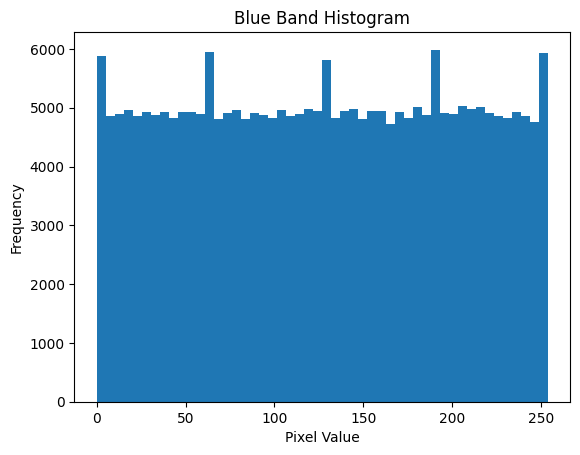

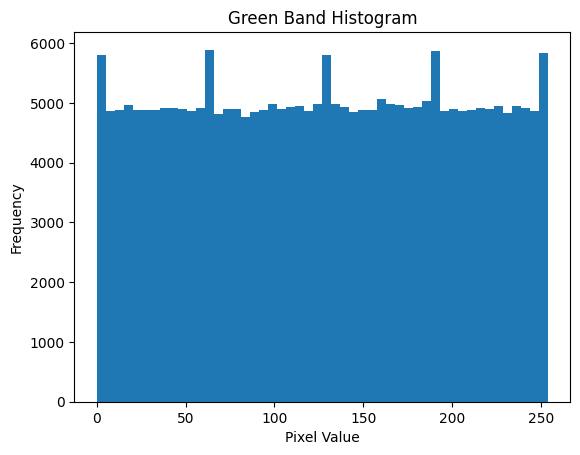

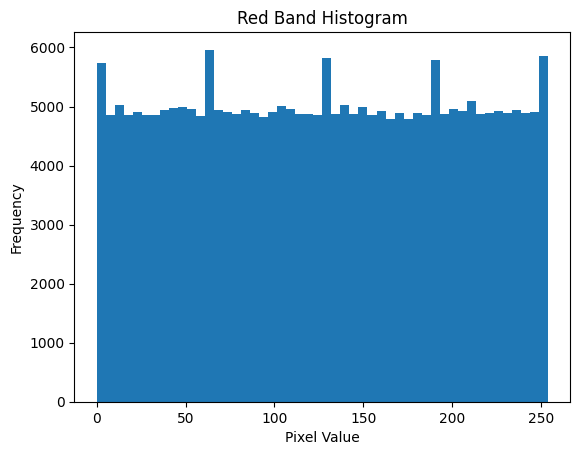


Band stacking completed.


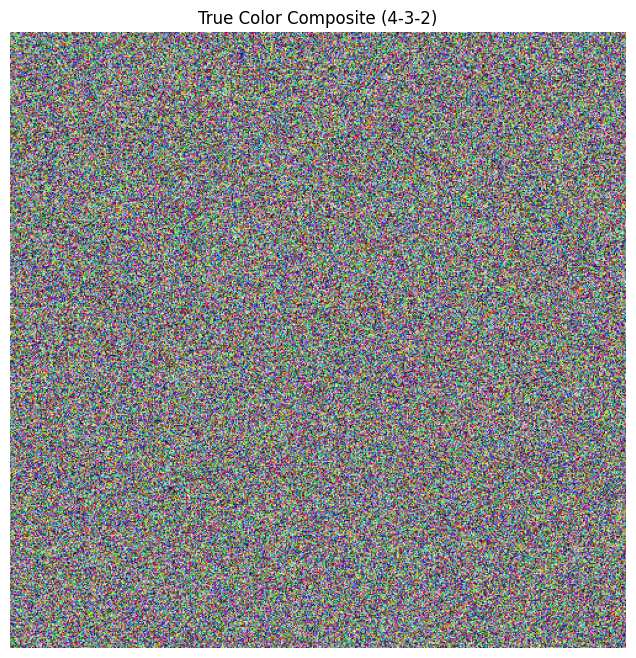

IndexError: band index 8 out of range (not in (1, 2, 3, 4))

In [4]:
import numpy as np
import rasterio
from rasterio.transform import from_origin

# 1.
width, height = 500, 500
bands = 4
data = np.random.randint(0, 255, size=(bands, height, width), dtype=np.uint8)

# 2.
transform = from_origin(70.0, 30.0, 0.0001, 0.0001)

# 3.
meta = {
    'driver': 'GTiff',
    'height': height,
    'width': width,
    'count': bands,
    'dtype': data.dtype,
    'crs': '+proj=latlong',
    'transform': transform
}

with rasterio.open('sentinel2.tif', 'w', **meta) as dst:
    dst.write(data)

print(" sentinel2.tif ")













import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.windows import Window

# ============================================
# INPUT FILE
# ============================================

file = "sentinel2.tif"


# ============================================
# 1. IMAGE INFORMATION
# ============================================

with rasterio.open(file) as src:

    print("===== IMAGE INFORMATION =====")
    print("Width:", src.width)
    print("Height:", src.height)
    print("Total Bands:", src.count)
    print("CRS:", src.crs)
    print("Pixel Size:", src.res)
    print("Data Type:", src.dtypes)

    # ========================================
    # 2. STATISTICS
    # ========================================

    print("\n===== BAND STATISTICS =====")

    for i in range(1, src.count + 1):

        band = src.read(i)

        print("\nBand", i)
        print("Minimum:", np.min(band))
        print("Maximum:", np.max(band))
        print("Mean:", np.mean(band))


    # ========================================
    # HISTOGRAMS
    # ========================================

    blue = src.read(2)
    green = src.read(3)
    red = src.read(4)

plt.figure()
plt.hist(blue.flatten(), bins=50)
plt.title("Blue Band Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(green.flatten(), bins=50)
plt.title("Green Band Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

plt.figure()
plt.hist(red.flatten(), bins=50)
plt.title("Red Band Histogram")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


# ============================================
# 3. BAND STACKING
# ============================================

with rasterio.open(file) as src:

    data = src.read()
    profile = src.profile

    profile.update(
        count=src.count,
        dtype=data.dtype
    )

    with rasterio.open("band_stacked.tif", "w", **profile) as dst:
        dst.write(data)

print("\nBand stacking completed.")


# ============================================
# 4. TRUE COLOR COMPOSITE
# ============================================

with rasterio.open(file) as src:

    red = src.read(4).astype(float)
    green = src.read(3).astype(float)
    blue = src.read(2).astype(float)


def normalize(band):

    return (band - band.min()) / (band.max() - band.min())


true_color = np.dstack((
    normalize(red),
    normalize(green),
    normalize(blue)
))

plt.figure(figsize=(8, 8))
plt.imshow(true_color)
plt.title("True Color Composite (4-3-2)")
plt.axis("off")
plt.show()


# ============================================
# FALSE COLOR COMPOSITE
# ============================================

with rasterio.open(file) as src:

    nir = src.read(8).astype(float)
    red = src.read(4).astype(float)
    green = src.read(3).astype(float)

false_color = np.dstack((
    normalize(nir),
    normalize(red),
    normalize(green)
))

plt.figure(figsize=(8, 8))
plt.imshow(false_color)
plt.title("False Color Composite (8-4-3)")
plt.axis("off")
plt.show()


# ============================================
# 5. CLIP AOI
# ============================================

with rasterio.open(file) as src:

    width = src.width
    height = src.height

    clip_width = width // 4
    clip_height = height // 4

    start_x = (width - clip_width) // 2
    start_y = (height - clip_height) // 2

    window = Window(
        start_x,
        start_y,
        clip_width,
        clip_height
    )

    data = src.read(window=window)

    transform = src.window_transform(window)

    profile = src.profile

    profile.update(
        width=clip_width,
        height=clip_height,
        transform=transform
    )

    with rasterio.open("clipped_area.tif", "w", **profile) as dst:
        dst.write(data)

print("AOI clipping completed.")


# ============================================
# 6. SPECTRAL SIGNATURE
# ============================================

with rasterio.open(file) as src:

    image = src.read()

    # Example pixel locations
    vegetation = (100, 100)
    water = (150, 150)
    urban = (200, 200)

    vegetation_values = image[:, vegetation[0], vegetation[1]]
    water_values = image[:, water[0], water[1]]
    urban_values = image[:, urban[0], urban[1]]

wavelengths = [
    443, 490, 560, 665,
    705, 740, 783, 842,
    865, 945, 1375, 1610, 2190
]

plt.figure(figsize=(10, 6))

plt.plot(
    wavelengths[:len(vegetation_values)],
    vegetation_values,
    marker="o",
    label="Vegetation"
)

plt.plot(
    wavelengths[:len(water_values)],
    water_values,
    marker="o",
    label="Water"
)

plt.plot(
    wavelengths[:len(urban_values)],
    urban_values,
    marker="o",
    label="Urban/Built-up"
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance / Pixel Value")
plt.title("Spectral Signature Curves")
plt.legend()
plt.grid()
plt.show()


# ============================================
# 7. NDVI
# ============================================

with rasterio.open(file) as src:

    nir = src.read(8).astype(float)
    red = src.read(4).astype(float)

    ndvi = (nir - red) / (nir + red)

plt.figure(figsize=(8, 6))
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI Map")
plt.axis("off")
plt.show()


# ============================================
# VEGETATION THRESHOLD
# ============================================

vegetation = np.where(ndvi > 0.3, 1, 0)

plt.figure(figsize=(8, 6))
plt.imshow(vegetation, cmap="gray")
plt.title("Vegetation Map (0 = No Vegetation, 1 = Vegetation)")
plt.axis("off")
plt.show()


# ============================================
# VEGETATION AREA
# ============================================

with rasterio.open(file) as src:

    pixel_width = abs(src.transform.a)
    pixel_height = abs(src.transform.e)

pixel_area = pixel_width * pixel_height

vegetation_pixels = np.sum(vegetation == 1)

vegetation_area_m2 = vegetation_pixels * pixel_area

vegetation_area_hectare = vegetation_area_m2 / 10000

print("\n===== VEGETATION AREA =====")
print("Vegetation Pixels:", vegetation_pixels)
print("Pixel Area:", pixel_area, "m²")
print("Vegetated Area:", vegetation_area_m2, "m²")
print("Vegetated Area:", vegetation_area_hectare, "hectares")


# ============================================
# SAVE VEGETATION MAP
# ============================================

with rasterio.open(file) as src:

    profile = src.profile

    profile.update(
        count=1,
        dtype=rasterio.uint8
    )

    with rasterio.open(
        "vegetation_map.tif",
        "w",
        **profile
    ) as dst:

        dst.write(
            vegetation.astype(rasterio.uint8),
            1
        )

print("\nVegetation map saved successfully.")